In [3]:
!pip install -q "transformers==4.53.3" accelerate

In [4]:
import transformers; print(transformers.__version__)   # должно быть 4.49.0

4.53.3


In [5]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

name = "tomg-group-umd/huginn-0125"
rev  = "bb6621b65e90b6a4b9b29ef88dc83866d450470c"   # фиксируем код модели из твоего трейсбэка

model = AutoModelForCausalLM.from_pretrained(
    name, revision=rev, torch_dtype=torch.bfloat16, trust_remote_code=True
).to("cuda").eval()
tok = AutoTokenizer.from_pretrained(name, revision=rev)

ids = tok("The capital of France is", return_tensors="pt").input_ids.to("cuda")
out = model.generate_with_adaptive_compute(ids, num_steps=32, max_new_tokens=10, tokenizer=tok)
print(tok.decode(out[0]))          # если Париж — победа, работает и load, и generate

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

<|begin_text|>The capital of France is Paris. It is the most populous city in France


In [6]:
mod = model.transformer.core_block[-1]
mod._forward_hooks.clear()                     # убрать хуки от прошлых упавших запусков

latents = []
def hook(m, i, o): latents.append(o.detach().float().cpu())
h = mod.register_forward_hook(hook)
try:
    torch.manual_seed(0)
    ids = tok("Q: 2+3=? A:", return_tensors="pt").input_ids.to("cuda")
    with torch.no_grad():
        model(input_ids=ids, num_steps=32)
finally:
    h.remove()                                 # снимется даже если forward упадёт

print("captured:", len(latents))               # теперь 32
traj = torch.stack([l[0, -1, :] for l in latents]).numpy()
print("trajectory shape:", traj.shape)         # (32, 5280)

captured: 32
trajectory shape: (32, 5280)


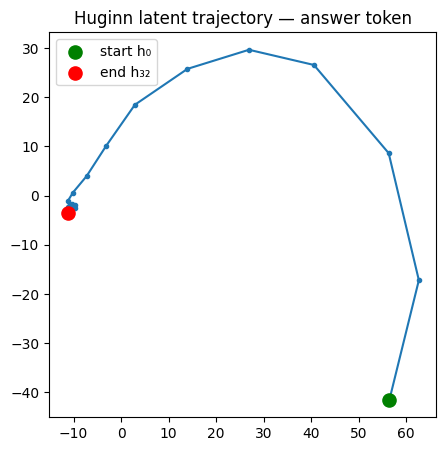

In [7]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
p = PCA(2).fit_transform(traj)
plt.figure(figsize=(5,5))
plt.plot(p[:,0], p[:,1], "-o", ms=3)
plt.scatter(*p[0], c="g", s=90, label="start h₀", zorder=3)
plt.scatter(*p[-1], c="r", s=90, label="end h₃₂", zorder=3)
plt.legend(); plt.title("Huginn latent trajectory — answer token")
plt.savefig("pca_trajectory.png", dpi=150, bbox_inches="tight"); plt.show()

In [8]:
import numpy as np
def winding_number(pts):
    c = pts.mean(0)
    v = pts - c
    ang = np.arctan2(v[:,1], v[:,0])
    d = np.diff(ang)
    d = (d + np.pi) % (2*np.pi) - np.pi     # разворот в (-π, π]
    return d.sum() / (2*np.pi)

print("winding (с h0):   ", round(winding_number(p), 3))
print("winding (без h0): ", round(winding_number(p[1:]), 3))

winding (с h0):    0.65
winding (без h0):  0.621


In [9]:
def get_trajectory(prompt, num_steps=32, seed=0):
    mod = model.transformer.core_block[-1]; mod._forward_hooks.clear()
    lat = []
    h = mod.register_forward_hook(lambda m,i,o: lat.append(o.detach().float().cpu()))
    try:
        torch.manual_seed(seed)
        ids = tok(prompt, return_tensors="pt").input_ids.to("cuda")
        with torch.no_grad():
            model(input_ids=ids, num_steps=num_steps)
    finally:
        h.remove()
    return torch.stack([l[0,-1,:] for l in lat]).numpy()

def winding_of(traj):
    return winding_number(PCA(2).fit_transform(traj)[1:])   # без h0

prompts = {
  "easy": "Q: 2+3=? A:",
  "hard": "Q: Alice has 3 apples, buys 4 more, gives 2 to Bob, then doubles what she has. How many? A:",
}
for name, pr in prompts.items():
    ws = [winding_of(get_trajectory(pr, seed=s)) for s in range(5)]   # 5 сидов
    print(f"{name:4s}  winding = {np.mean(ws):.3f} ± {np.std(ws):.3f}")

easy  winding = 0.380 ± 0.512
hard  winding = -0.134 ± 0.659


In [10]:
import time
for _ in range(2):
    t = time.time(); _ = get_trajectory("Q: 2+3=? A:"); print(round(time.time()-t, 2), "s")

2.64 s
2.57 s
